# Helsinki City Bike Trips: Summer 2021 Analysis
This is a personal project made within the purview of the course 2568 Python Programming for Business Intelligence at Hanken School of Economics.

## Project goal
Analyse when, where, and how Helsinki residents ride city bikes during summer 2021.
In this project, I specifically aim to address the following questions:

1. When are bikes used most (hour of day, weekday vs. weekend, month)?
2. What are typical trip distances and durations?
3. Which stations are the busiest?
4. How does weather (temperature, rain) affect bike usage?


## Data sources
- **Trip data**: HSL / Helsinki Region Infoshare: journeys made by city bikes
- **Station metadata**: HSL open data portal (coordinates, names, cities) - not necessary for the main analytic component of this project, but the dataset features interesting columns such as station capacity 
- **Weather data**: Open-Meteo Historical Weather Online API


## Trip dataset description: City Bike Origin–Destination Data (April–October 2021)
The dataset records individual city bike journeys and includes the origin and destination stations, start and end times, distance travelled in meters, and trip duration in seconds.


## Project Structure
The project is organised into the following sections:

0. **Pipeline diagram**
1. **Imports** - all required libraries
2. **Data loading** - downloads and saves raw data from HSL and Open-Meteo
3. **Data cleaning** - parses, filters, and transforms the raw data
4. **Descriptive statistics and visuals** - summary statistics and visualizations
5. **Weather data** - fetches weather data and merges it onto the trip data
6. **Statistical analysis** - t-tests and regression models
7. **Export** - saves cleaned data and results to data/processed/



.





## How to run this notebook

1. Open `project.ipynb`.
2. Run all cells from top to bottom.
3. The notebook downloads raw trip and weather data, saves raw files to `data/raw/`, cleans and analyzes the data, and exports cleaned datasets and figures to `data/processed/`.
4. No API key is required.

The raw data is downloaded by default, but the notebook also includes optional commented-out lines in Chapter 3 for loading previously saved raw files from `data/raw/`.

Expected folder structure:
```text
my-project/
├── project.ipynb
├── helsinki_citybike_pipeline.svg
└── data/
    ├── raw/
    │   └── original input data
    └── processed/
        └── cleaned data and exported results
```


## 0. Pipeline diagram

![Data pipeline](helsinki_citybike_pipeline.svg)


## 1. Imports

In [6]:
import zipfile
import requests
import os
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# install packages as needed

## 2. Data loading

In [8]:
# Create folder structure
os.makedirs("data/raw/od-trips-2021", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
print("Folders created.")

# Download the 2021 annual zip and save locally
zip_url = "https://dev.hsl.fi/citybikes/od-trips-2021/od-trips-2021.zip"
zip_path = "data/raw/od-trips-2021.zip"
extract_folder = "data/raw/od-trips-2021"

print("Downloading annual data package...")
response = requests.get(zip_url)
response.raise_for_status() # Check if download was successful or not

with open(zip_path, "wb") as f:
    f.write(response.content)
print("Download complete.")

# Extract ZIP
print("Extracting ZIP file...")
with zipfile.ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(extract_folder)
print("Extraction complete.")

Folders created.
Download complete.
Extracting ZIP file...
Extraction complete.


## 3. Load and combine monthly CSVs and station metadata

In [10]:
# Sanity check folder where monthly CSV files were extracted 
csv_files = [f for f in os.listdir(extract_folder) if f.endswith(".csv")]
print(f"Found {len(csv_files)} CSV files: {csv_files}")

# Add each monthly .csv to a list and then combine into a larger df  
monthly_frames = []
for f in csv_files:
    df_month = pd.read_csv(os.path.join(extract_folder, f))
    monthly_frames.append(df_month)

trips_raw = pd.concat(monthly_frames, ignore_index=True)
print(f"Total rows loaded: {len(trips_raw):,}")

trips_raw.to_csv("data/raw/trips_raw.csv", index=False)
print("Raw trip data saved to data/raw/trips_raw.csv")

trips_raw


Found 7 CSV files: ['2021-04.csv', '2021-05.csv', '2021-06.csv', '2021-07.csv', '2021-08.csv', '2021-09.csv', '2021-10.csv']
Total rows loaded: 2,862,102
Raw trip data saved to data/raw/trips_raw.csv


,Departure,Return,Departure station id,Departure station name,Return station id,Return station name,Covered distance (m),Duration (sec.)
0,2021-04-30T23:59:54,2021-05-01T00:08:15,16,Liisanpuistikko,2,Laivasillankatu,1885.0,499.0
1,2021-04-30T23:59:52,2021-05-01T00:16:16,20,Kaisaniemenpuisto,112,Rautatieläisenkatu,3359.0,984.0
2,2021-04-30T23:59:52,2021-05-01T00:13:40,4,Viiskulma,33,Kauppakorkeakoulu,1633.0,824.0
3,2021-04-30T23:59:43,2021-05-01T00:23:22,133,Paavalinpuisto,241,Agronominkatu,6459.0,1418.0
4,2021-04-30T23:59:41,2021-05-01T00:16:15,20,Kaisaniemenpuisto,112,Rautatieläisenkatu,3210.0,990.0
...,...,...,...,...,...,...,...,...
2862097,2021-10-01T00:03:21,2021-10-01T00:21:56,23,Kiasma,142,Koskelantie,4772.0,NaN
2862098,2021-10-01T00:02:38,2021-10-01T00:15:54,19,Rautatientori / itä,58,Lauttasaarensilta,3493.0,NaN
2862099,2021-10-01T00:01:48,2021-10-01T00:11:19,96,Huopalahdentie,208,Valimotie,2109.0,NaN
2862100,2021-10-01T00:01:16,2021-10-01T00:58:59,8,Vanha kirkkopuisto,133,Paavalinpuisto,5883.0,NaN


In [ ]:
# Uncomment these lines to skip the download and load from saved files instead:
# trips_raw = pd.read_csv("data/raw/trips_raw.csv")
# stations_raw = pd.read_csv("data/raw/stations_raw.csv")

In [11]:
# Import station metadata
station_url = "https://opendata.arcgis.com/datasets/726277c507ef4914b0aec3cbcfcbfafc_0.csv"

stations_raw = pd.read_csv(station_url)

stations_raw.to_csv("data/raw/stations_raw.csv", index=False)

print("Stations loaded and saved:", len(stations_raw), "rows")
stations_raw

Stations loaded and saved: 457 rows


,FID,ID,Nimi,Namn,Name,Osoite,Adress,Kaupunki,Stad,Operaattor,Kapasiteet,x,y,x2,y2
0,1,501,Hanasaari,Hanaholmen,Hanasaari,Hanasaarenranta 1,Hanaholmsstranden 1,Espoo,Esbo,CityBike Finland,10,24.840319,60.165820,2.549113e+07,6.672558e+06
1,2,503,Keilalahti,Kägelviken,Keilalahti,Keilalahdentie 2,Kägelviksvägen 2,Espoo,Esbo,CityBike Finland,28,24.827467,60.171524,2.549042e+07,6.673195e+06
2,3,505,Westendinasema,Westendstationen,Westendinasema,Westendintie 1,Westendvägen 1,Espoo,Esbo,CityBike Finland,16,24.805758,60.168266,2.548922e+07,6.672836e+06
3,4,507,Golfpolku,Golfstigen,Golfpolku,Golfpolku 3,Golfstigen 3,Espoo,Esbo,CityBike Finland,16,24.796136,60.168143,2.548868e+07,6.672824e+06
4,5,509,Revontulentie,Norrskensvägen,Revontulentie,Revontulentie 10,Norrskensvägen 10,Espoo,Esbo,CityBike Finland,30,24.802938,60.171551,2.548906e+07,6.673202e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,453,401,Koivusaari (M),Björkholmens metrostation,Koivusaari metro station,Sotkatie 11,Dykandsvägen 11,,,,16,24.855164,60.163386,2.549196e+07,6.672285e+06
453,454,402,Bermudankuja,Bermudagränden,Välimerenkatu,Atlantinkatu 10,Atlantgatan 10,,,,16,24.910142,60.154904,2.549501e+07,6.671335e+06
454,455,403,Verkkosaari,Nätholmen,Verkkosaari,Tukkutorinkuja 3,Partitorgsgränden,,,,20,24.977548,60.189556,2.549875e+07,6.675192e+06
455,456,404,Sompasaari,Sumparn,Sompasaari,Sompasaarenlaituri 2,Sumparkajen 2,,,,14,24.976076,60.182931,2.549867e+07,6.674454e+06


## 3. Data cleaning

### 3.1 Column name cleaning

In [15]:
# Keep raw data as it is
trips = trips_raw.copy()
trips.info()

# Standardise messy column names
trips.columns = (trips.columns
                 .str.lower()
                 .str.replace(" ", "_")
                 .str.replace("(", "")
                 .str.replace(")", "")
                 .str.replace(".", "")
                )
print()
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2862102 entries, 0 to 2862101
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Departure               object 
 1   Return                  object 
 2   Departure station id    int64  
 3   Departure station name  object 
 4   Return station id       int64  
 5   Return station name     object 
 6   Covered distance (m)    float64
 7   Duration (sec.)         float64
dtypes: float64(2), int64(2), object(4)
memory usage: 174.7+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2862102 entries, 0 to 2862101
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   departure               object 
 1   return                  object 
 2   departure_station_id    int64  
 3   departure_station_name  object 
 4   return_station_id       int64  
 5   return_station_name     object 
 6   covered_distance_m      float64
 7   dur

### 3.2 Data cleaning

In [17]:
# Parse timestamps (convert to dt)
trips["departure"] = pd.to_datetime(trips["departure"], errors="coerce")
trips["return"]    = pd.to_datetime(trips["return"], errors="coerce")

# Drop rows where timestamp parsing failed
before_parse = len(trips)
trips = trips.dropna(subset=["departure", "return"])
print(f"Dropped {before_parse - len(trips):,} rows due to unparseable timestamps.")

# Fill missing duration values manually by calculating difference between departure and return timestamps
trips["duration_sec"] = trips["duration_sec"].fillna(
    (trips["return"] - trips["departure"]).dt.total_seconds()
)

# Convert to more readable units
trips["distance_km"]  = trips["covered_distance_m"] / 1000
trips["duration_min"] = trips["duration_sec"] / 60

# Extract useful time features
trips["hour"]    = trips["departure"].dt.hour
trips["weekday"] = trips["departure"].dt.day_name()
trips["date"]    = trips["departure"].dt.date
trips["month"]   = trips["departure"].dt.month


Dropped 12 rows due to unparseable timestamps.


### 3.3 Data transformation

In [19]:
# Classify trips as weekday or weekend
weekend_days = ["Saturday", "Sunday"]
trips["day_type"] = trips["weekday"].apply(lambda d: "Weekend" if d in weekend_days else "Weekday")

# Calculate average speed in km/h
trips["speed_kmh"] = trips["distance_km"] / (trips["duration_min"] / 60)

# Remove implausibly short or long trips:
# - Under 10m or 30s: not a real trip, likely a failed dock attempt etc. 
# - Over 100km or 24h: physically implausible or unreturned bike
before = len(trips)
trips = trips[
    (trips["distance_km"] > 0.01) & (trips["duration_min"] > 0.5) &
    (trips["distance_km"] < 100) & (trips["duration_min"] < 1440)
]
after = len(trips)

print(f"Removed {before - after:,} invalid or unrealistic rows ({before:,} --> {after:,})")
trips

Removed 110,559 invalid or unrealistic rows (2,862,090 --> 2,751,531)


,departure,return,departure_station_id,departure_station_name,return_station_id,return_station_name,covered_distance_m,duration_sec,distance_km,duration_min,hour,weekday,date,month,day_type,speed_kmh
0,2021-04-30 23:59:54,2021-05-01 00:08:15,16,Liisanpuistikko,2,Laivasillankatu,1885.0,499.0,1.885,8.316667,23,Friday,2021-04-30,4,Weekday,13.599198
1,2021-04-30 23:59:52,2021-05-01 00:16:16,20,Kaisaniemenpuisto,112,Rautatieläisenkatu,3359.0,984.0,3.359,16.400000,23,Friday,2021-04-30,4,Weekday,12.289024
2,2021-04-30 23:59:52,2021-05-01 00:13:40,4,Viiskulma,33,Kauppakorkeakoulu,1633.0,824.0,1.633,13.733333,23,Friday,2021-04-30,4,Weekday,7.134466
3,2021-04-30 23:59:43,2021-05-01 00:23:22,133,Paavalinpuisto,241,Agronominkatu,6459.0,1418.0,6.459,23.633333,23,Friday,2021-04-30,4,Weekday,16.398025
4,2021-04-30 23:59:41,2021-05-01 00:16:15,20,Kaisaniemenpuisto,112,Rautatieläisenkatu,3210.0,990.0,3.210,16.500000,23,Friday,2021-04-30,4,Weekday,11.672727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2862097,2021-10-01 00:03:21,2021-10-01 00:21:56,23,Kiasma,142,Koskelantie,4772.0,1115.0,4.772,18.583333,0,Friday,2021-10-01,10,Weekday,15.407354
2862098,2021-10-01 00:02:38,2021-10-01 00:15:54,19,Rautatientori / itä,58,Lauttasaarensilta,3493.0,796.0,3.493,13.266667,0,Friday,2021-10-01,10,Weekday,15.797487
2862099,2021-10-01 00:01:48,2021-10-01 00:11:19,96,Huopalahdentie,208,Valimotie,2109.0,571.0,2.109,9.516667,0,Friday,2021-10-01,10,Weekday,13.296673
2862100,2021-10-01 00:01:16,2021-10-01 00:58:59,8,Vanha kirkkopuisto,133,Paavalinpuisto,5883.0,3463.0,5.883,57.716667,0,Friday,2021-10-01,10,Weekday,6.115738


## 4. Descriptive statistics and visuals


In [21]:
trips[["distance_km", "duration_min", "speed_kmh"]].describe().round(2)

,distance_km,duration_min,speed_kmh
count,2751531.00,2751531.00,2751531.00
mean,2.46,15.45,11.53
std,1.75,41.66,3.35
min,0.01,0.52,0.00
25%,1.19,6.58,9.73
50%,2.02,10.95,11.76
75%,3.31,17.63,13.68
max,73.22,1439.45,46.36


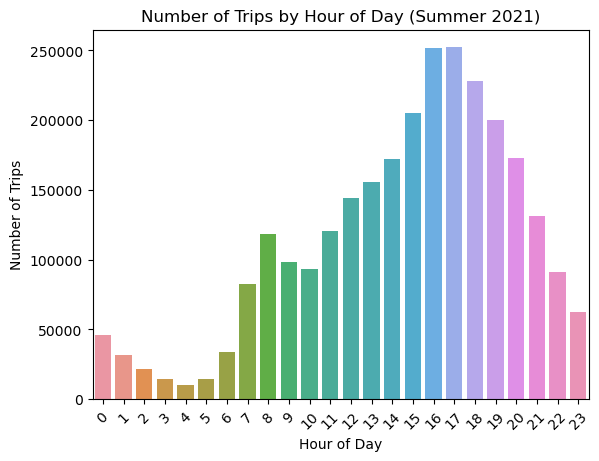

In [22]:
# Figure 1 - trips per hour of day
plt.figure()
sns.countplot(x="hour", data=trips, order=range(24))
plt.xticks(rotation=45)
plt.title("Number of Trips by Hour of Day (Summer 2021)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.savefig("data/processed/trips_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

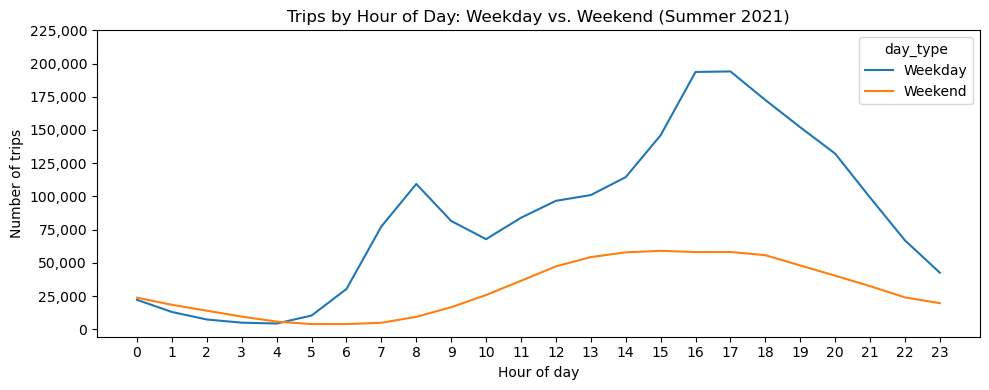

In [23]:
# Visualization: Trips by hour of day — weekday vs. weekend
hourly_by_daytype = trips.groupby(["hour", "day_type"]).size().reset_index(name="trip_count")

plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_by_daytype, x="hour", y="trip_count", hue="day_type")
plt.title("Trips by Hour of Day: Weekday vs. Weekend (Summer 2021)")
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.xticks(range(0, 24, 1))
plt.yticks(range(0, 225001, 25000), [f"{x:,}" for x in range(0, 225001, 25000)])
plt.tight_layout()
plt.savefig("data/processed/trips_by_hour_weekday_vs_weekend.png", dpi=150, bbox_inches="tight")
plt.show()

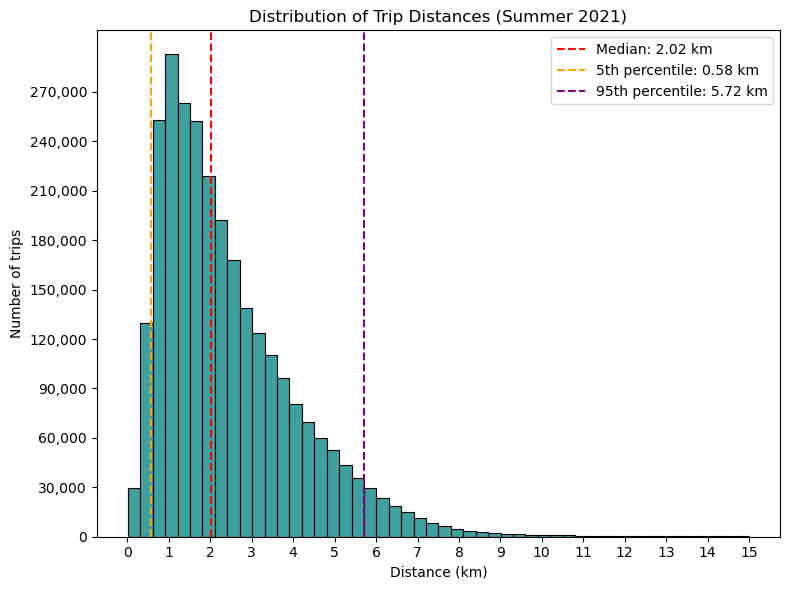

In [24]:
# Visualization: Distribution of trip distances
trips_under20km = trips[trips["distance_km"] <= 15]  # keep trips ≤ 15 km, otherwise outliers blow up the visualization
median = trips_under20km["distance_km"].median()
p5 = trips_under20km["distance_km"].quantile(0.05)
p95 = trips_under20km["distance_km"].quantile(0.95)

plt.figure(figsize=(8,6))
sns.histplot(trips_under20km["distance_km"], bins=50, color="teal")
plt.axvline(median, color="red",    linestyle="--", label=f"Median: {median:.2f} km")
plt.axvline(p5,     color="orange", linestyle="--", label=f"5th percentile: {p5:.2f} km")
plt.axvline(p95,    color="purple", linestyle="--", label=f"95th percentile: {p95:.2f} km")
plt.xlabel("Distance (km)")
plt.ylabel("Number of trips")
plt.title("Distribution of Trip Distances (Summer 2021)")
plt.xticks(range(0, 16, 1))
plt.yticks(range(0, 270001, 30000), [f"{x:,}" for x in range(0, 270001, 30000)])
plt.legend()
plt.tight_layout()
plt.savefig("data/processed/distribution_of_trip_distances.png", dpi=150, bbox_inches="tight")
plt.show()


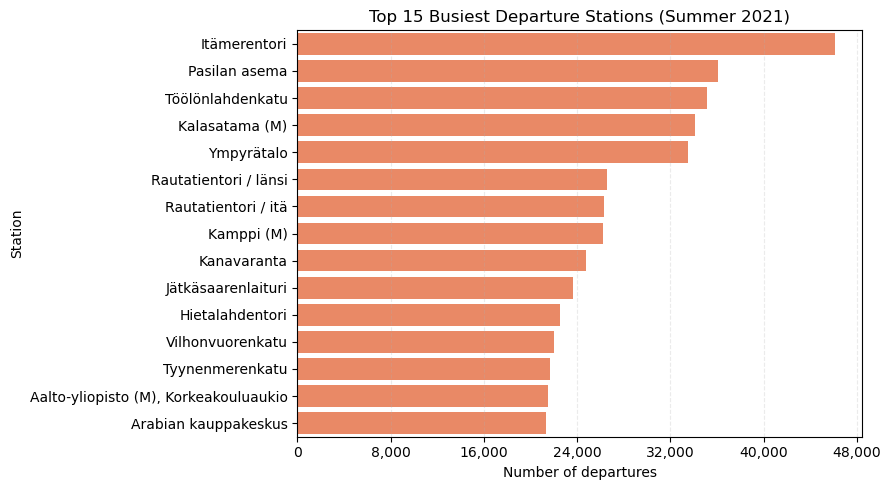

In [25]:
top_stations = trips["departure_station_name"].value_counts().head(15).reset_index()
top_stations.columns = ["station", "trip_count"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_stations, x="trip_count", y="station", color="coral", ax=ax)
ax.set_title("Top 15 Busiest Departure Stations (Summer 2021)")
ax.set_xlabel("Number of departures")
ax.set_ylabel("Station")
plt.xticks(range(0, 50001, 8000), [f"{x:,}" for x in range(0, 50001, 8000)])
plt.tight_layout()
plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.savefig("data/processed/top_15_departure_stations.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Weather data

In [27]:
weather_url = "https://archive-api.open-meteo.com/v1/archive"
# Helsinki's exact latitude and longitude is not clearly defined, but I took the rough average from several sources
params = {
    "latitude": 60.1802,
    "longitude": 24.9384,
    "start_date": "2021-04-01",
    "end_date": "2021-10-31",
    "hourly": "temperature_2m,precipitation",
    "timezone": "Europe/Helsinki",
}

response = requests.get(weather_url, params=params)
response.raise_for_status()
weather_json = response.json()

weather = pd.DataFrame({
    "datetime":         pd.to_datetime(weather_json["hourly"]["time"]),
    "temperature_c":    weather_json["hourly"]["temperature_2m"],
    "precipitation_mm": weather_json["hourly"]["precipitation"],
})

weather.to_csv("data/raw/weather_raw.csv", index=False)

print(f"Weather records fetched: {len(weather):,}")
display(weather.head())

Weather records fetched: 5,136


,datetime,temperature_c,precipitation_mm
0,2021-04-01 00:00:00,0.6,0.0
1,2021-04-01 01:00:00,0.2,0.0
2,2021-04-01 02:00:00,-0.2,0.0
3,2021-04-01 03:00:00,0.1,0.0
4,2021-04-01 04:00:00,-0.1,0.0


In [28]:
# Round departure time down to the nearest hour so it matches the weather data
trips["departure_hour"] = trips["departure"].dt.floor("h")

trips_with_weather = trips.merge(
    weather.rename(columns={"datetime": "departure_hour"}),
    on="departure_hour",
    how="left"
)
# Add weekend columns
trips_with_weather["is_weekend"] = trips_with_weather["day_type"] == "Weekend"

print(f"Trips with weather data: {trips_with_weather['temperature_c'].notna().sum():,}")
display(trips_with_weather[["departure", "temperature_c", "precipitation_mm", "distance_km"]].head())

Trips with weather data: 2,751,531


,departure,temperature_c,precipitation_mm,distance_km
0,2021-04-30 23:59:54,4.5,0.0,1.885
1,2021-04-30 23:59:52,4.5,0.0,3.359
2,2021-04-30 23:59:52,4.5,0.0,1.633
3,2021-04-30 23:59:43,4.5,0.0,6.459
4,2021-04-30 23:59:41,4.5,0.0,3.210


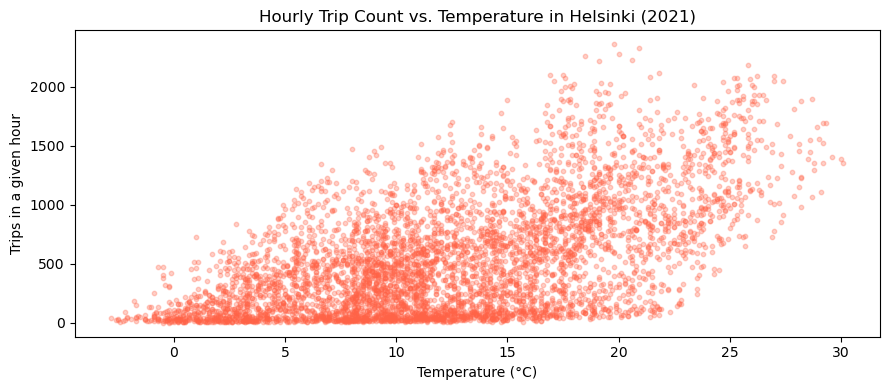

Correlation between temperature and hourly trip count: 0.57


In [29]:
hourly_weather = (trips_with_weather
                  .groupby("departure_hour")
                  .agg(trip_count=("distance_km", "count"),
                       avg_temp=("temperature_c", "mean"))
                  .reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(hourly_weather["avg_temp"], hourly_weather["trip_count"],
           alpha=0.3, color="tomato", s=10)
ax.set_title("Hourly Trip Count vs. Temperature in Helsinki (2021)")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Trips in a given hour")
plt.tight_layout()
plt.savefig("data/processed/trips_by_temp.png", dpi=150, bbox_inches="tight")
plt.show()

corr = hourly_weather["avg_temp"].corr(hourly_weather["trip_count"])
print(f"Correlation between temperature and hourly trip count: {corr:.2f}")

In [30]:
trips_with_weather["is_rainy"] = trips_with_weather["precipitation_mm"] > 0.1

rain_summary = (trips_with_weather
                .groupby("is_rainy")
                .agg(total_trips=("distance_km", "count"),
                     avg_distance_km=("distance_km", "mean"))
                .reset_index())

rain_summary["is_rainy"] = rain_summary["is_rainy"].map({True: "Rainy", False: "Dry"})
display(rain_summary)
print("On average, trips during dry days are 0.17km longer than trips on rainy days")  

,is_rainy,total_trips,avg_distance_km
0,Dry,2528879,2.476516
1,Rainy,222652,2.304159


On average, trips during dry days are 0.17km longer than trips on rainy days


## 6. Statistical analysis

### 6.1 t-test: weekday vs. weekend trip distances

In [33]:
# H0: There is no difference in average trip distance between weekdays and weekends
# H1: There is a difference in average trip distance between weekdays and weekends

weekday_trips = trips[trips["day_type"] == "Weekday"]
weekend_trips = trips[trips["day_type"] == "Weekend"]

weekday_mean = weekday_trips['distance_km'].mean()
weekend_mean = weekend_trips['distance_km'].mean()
difference = weekend_mean - weekday_mean

print(f"Weekday mean distance : {weekday_mean:.2f} km")
print(f"Weekend mean distance : {weekend_mean:.2f} km")

t_stat, p_value = stats.ttest_ind(
    weekday_trips["distance_km"],
    weekend_trips["distance_km"],
)

print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.7f}")
print()
print("Null hypothesis is rejected even on 1% significance level.") 
print("There is a significant difference in average trip distance between weekdays and weekends.")
print(f"Weekend trips are on average {difference:.2f} km longer than weekday trips.")

Weekday mean distance : 2.43 km
Weekend mean distance : 2.57 km

t-statistic : -58.3986
p-value     : 0.0000000

Null hypothesis is rejected even on 1% significance level.
There is a significant difference in average trip distance between weekdays and weekends.
Weekend trips are on average 0.14 km longer than weekday trips.


### 6.2 t-test: weekday vs. weekend trip durations

In [35]:
# H0: There is no difference in average trip duration between weekdays and weekends
# H1: There is a difference in average trip duration between weekdays and weekends

weekday_mean_dur = weekday_trips["duration_min"].mean()
weekend_mean_dur = weekend_trips["duration_min"].mean()
difference_dur   = weekend_mean_dur - weekday_mean_dur

print(f"Weekday mean duration : {weekday_mean_dur:.2f} min")
print(f"Weekend mean duration : {weekend_mean_dur:.2f} min")

t_stat, p_value = stats.ttest_ind(
    weekday_trips["duration_min"],
    weekend_trips["duration_min"],
)

print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.7f}")
print()
print("Null hypothesis is rejected even on 1% significance level.")
print("There is a significant difference in average trip duration between weekdays and weekends.")
print(f"Weekend trips are on average {difference_dur:.2f} minutes ({difference_dur * 60:.0f} seconds) longer than weekday trips.")

Weekday mean duration : 14.95 min
Weekend mean duration : 16.84 min

t-statistic : -33.1413
p-value     : 0.0000000

Null hypothesis is rejected even on 1% significance level.
There is a significant difference in average trip duration between weekdays and weekends.
Weekend trips are on average 1.89 minutes (113 seconds) longer than weekday trips.


### 6.3 Regression 1: Weekday vs. Weekend controlling for temperature and rain


In [37]:
import statsmodels.api as sm

# Define regression dataframe
reg_df = trips_with_weather[
    ["distance_km", "is_weekend", "temperature_c", "precipitation_mm"]
].copy()

# Convert weekend dummy to 0/1
reg_df["is_weekend"] = reg_df["is_weekend"].astype(int)

# Remove rows with missing values in any regression variable
reg_df = reg_df.dropna()

# Define dependent and independent variables
y = reg_df["distance_km"]
X = reg_df[["is_weekend", "temperature_c", "precipitation_mm"]]

# Add constant/intercept
X = sm.add_constant(X)

# Run OLS with heteroskedasticity-robust standard errors
model_weekend = sm.OLS(y, X).fit(cov_type="HC3")

print(model_weekend.summary())


                            OLS Regression Results                            
Dep. Variable:            distance_km   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2281.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        22:07:54   Log-Likelihood:            -5.4377e+06
No. Observations:             2751531   AIC:                         1.088e+07
Df Residuals:                 2751527   BIC:                         1.088e+07
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.3200      0.003  

### Regression 1 results: trip distance ~ is_weekend + temperature + precipitation

All three variables are highly significant (p < 0.001). Interpreting the coefficients:

- **Intercept (2.32)**: the baseline average trip distance on a dry weekday at 0°C is 2.32 km.
- **is_weekend (0.14)**: weekend trips are on average 0.14 km longer than weekday trips, controlling for temperature and rain. This is consistent with the t-test results in section 6.1.
- **temperature_c (0.007)**: each additional degree Celsius is associated with a 0.007 km increase in average trip distance. The effect is small but statistically significant.
- **precipitation_mm (-0.13)**: each additional mm of hourly rain is associated with a 0.13 km decrease in average trip distance. Rain has the strongest practical effect among the included weather variables.


### 6.4 Regression 2a: Trip distance and hourly precipitation


In [40]:
rain_df = trips_with_weather[["distance_km", "precipitation_mm"]].dropna()

# Model: trip distance ~ hourly_precipitation_mm
model_hourly_rain = sm.OLS(rain_df["distance_km"], sm.add_constant(rain_df[["precipitation_mm"]])).fit(cov_type="HC3")
print(model_hourly_rain.summary())

                            OLS Regression Results                            
Dep. Variable:            distance_km   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1692.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        22:07:55   Log-Likelihood:            -5.4403e+06
No. Observations:             2751531   AIC:                         1.088e+07
Df Residuals:                 2751529   BIC:                         1.088e+07
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.4718      0.001  

### Regression 2a results: trip distance ~ hourly precipitation

Both coefficients are highly significant (p < 0.001). Interpreting the coefficients:

- **Intercept (2.47)**: the baseline average trip distance during a dry hour is 2.47 km.
- **precipitation_mm (-0.14)**: each additional mm of hourly rain is associated with a 0.14 km decrease in average trip distance.
- **Very low adjusted R-squared**: hourly rain explains very little of the total variation in trip distance, even though the coefficient is statistically significant.


In [42]:
daily_rain = (trips_with_weather
              .groupby("date")["precipitation_mm"]
              .sum()
              .reset_index()
              .rename(columns={"precipitation_mm": "daily_precipitation_mm"}))

trips_with_daily_rain = trips_with_weather.merge(daily_rain, on="date", how="left")

daily_rain_df = trips_with_daily_rain[["distance_km", "daily_precipitation_mm"]].dropna()

X = daily_rain_df[["daily_precipitation_mm"]]
y = daily_rain_df["distance_km"]

X_with_const = sm.add_constant(X)

model_daily_rain = sm.OLS(y, X_with_const).fit(cov_type="HC3")
print(model_daily_rain.summary())

                            OLS Regression Results                            
Dep. Variable:            distance_km   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1389.
Date:                Sun, 10 May 2026   Prob (F-statistic):          7.61e-304
Time:                        22:07:58   Log-Likelihood:            -5.4404e+06
No. Observations:             2751531   AIC:                         1.088e+07
Df Residuals:                 2751529   BIC:                         1.088e+07
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2

## Regression 2b results: trip distance ~ daily total precipitation

Both coefficients are highly significant (p < 0.001). Interpreting the coefficients:

- **Intercept (2.48)**: the baseline average trip distance on a dry day is 2.48 km
- **daily_precipitation_mm (-0.000025)**: each additional mm of daily total precipitation reduces average trip distance by 0.000025 km — a negligible effect in practical terms

The extremely small adjusted R-squared of 0.000 indicates that daily total precipitation explains practically none of the variation in trip distance. Comparing to regression 2a, hourly precipitation (adj. R-squared = 0.001, coef = -0.14) is a meaningfully stronger predictor than daily total precipitation (adj. R-squared = 0.000, coef = -0.000025). This result suggests that people react to current hourly weather conditions rather than the overall rainfall of the day. Cyclists do not seem to internalize the daily weather forecast when deciding how far to ride.

## 7. Export data and results

In [71]:
# Export cleaned trip data
trips_with_weather.to_csv("data/processed/trips_cleaned.csv", index=False)
print("Cleaned trip data saved to data/processed/trips_cleaned.csv")

# Export daily summary
daily_summary = (trips_with_weather
                 .groupby("date")
                 .agg(trip_count=("distance_km", "count"),
                      avg_distance_km=("distance_km", "mean"),
                      avg_temp=("temperature_c", "mean"))
                 .reset_index())

daily_summary.to_csv("data/processed/daily_summary.csv", index=False)
print("Daily summary saved to data/processed/daily_summary.csv")

# Export station summary
station_summary = (trips_with_weather
                   .groupby("departure_station_name")
                   .agg(trip_count=("distance_km", "count"),
                        avg_distance_km=("distance_km", "mean"),
                        avg_duration_min=("duration_min", "mean"))
                   .reset_index()
                   .sort_values("trip_count", ascending=False))

station_summary.to_csv("data/processed/station_summary.csv", index=False)
print("Station summary saved to data/processed/station_summary.csv")

display(station_summary.head())

Cleaned trip data saved to data/processed/trips_cleaned.csv
Daily summary saved to data/processed/daily_summary.csv
Station summary saved to data/processed/station_summary.csv


,departure_station_name,trip_count,avg_distance_km,avg_duration_min
103,Itämerentori,46147,2.120516,13.973748
294,Pasilan asema,36061,2.403834,14.214925
417,Töölönlahdenkatu,35108,2.213320,14.397930
120,Kalasatama (M),34127,2.291832,14.750147
460,Ympyrätalo,33526,2.495441,15.716431



## Conclusion
**Time-related patterns:**  
Peak usage occurs during the morning commute (~ 8 AM) and afternoon/evening (~ 17–18),
confirming that city bikes are heavily used for commuting on weekdays. Weekends also show
a flatter, more spread-out usage pattern, which might suggest more leisure trips.

**Trip characteristics:**  
Typical bike trips are short, with a median distance of around 2 km and a median duration
under 15 minutes.


**Weekday vs. weekend:**  
Both t-tests rejected the null hypothesis at the 1% significance level: weekend trips
are longer in distance and longer in duration than weekday trips. The regression
confirms this holds even after controlling for temperature and rain, with weekend trips
averaging 0.14 km longer than weekday trips.

**Weather effects:**  
Temperature has a small but significant positive effect on trip distance. Rain has a
clear negative effect on bike usage: each additional mm of hourly precipitation reduces average trip distance by 0.14 km. Comparing the two rain regressions, hourly precipitation is a stronger predictor than daily total precipitation, suggesting that cyclists react to current weather conditions rather than the overall rainfall forecast for the day. This may be due to the widespread presence of public transport options, which function as a strong substitute for city bikes, especially when weather conditions are poor. 

**Busiest stations:**  The busiest departure stations are concentrated near the city centre and major transit
hubs, consistent with the commuting pattern observed in the time-pattern analysis..

## Statement of AI use

Claude (Sonnet 4.6) by Anthropic and ChatGPT (GPT-5.3) by OpenAI were used to help structure the project outline, suggest the Open-Meteo API as an accessible key-free weather data source, and help with the folder structure and data loading code. I also used AI to help with list comprehensions and lambda functions, and to write certain code snippets more concisely. AI was used to create the pipeline diagram. All analytical decisions, interpretation of results, and written conclusions are my own.